# Load Qick

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_3 import system_cfg
from single_qubit_pyscrip_v1_3.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg
print(soccfg)
print(system_cfg.DATA_PATH)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_3164ddee6b4c4f47a277170fda727fd7@192.168.10.82:43357
QICK running on ZCU216, software version 0.2.367

Firmware configuration (built Fri Sep 13 20:50:31 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

In [ ]:
# from YOKOGS200 import YOKOGS200
# import pyvisa 
# rm = pyvisa.ResourceManager()
# yoko_connect='USB0::0x0B21::0x0039::91WB18859::INSTR'
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# # yoko.OutputOff()

# Qubit setting

In [2]:
# Define the qubit index
qubit_idx = 0

config={
    **system_cfg.hw_cfg,
    **system_cfg.readout_cfg,
    **system_cfg.qubit_cfg,
    **system_cfg.expt_cfg,
    **system_cfg.cool_cfg}


In [3]:
from qubit import Fluxonium
from qubit import phi_to_flux, flux_to_phi

target_phi = 0.5 # Target flux value in the range [0, 1]
target_flux = -2.2
phi = flux_to_phi(target_flux, (-7.99, 3.57), (0, 0.5))
flux = phi_to_flux(target_phi, (-7.99, 3.57), (0, 0.5))

q = Fluxonium(EJ = 5.57, EC=0.966, EL=0.702, dimention=51, flux=phi)


flux = phi_to_flux(target_phi, (-7.99, 3.57), (0, 0.5))
print('V=', flux)
phi = flux_to_phi(target_flux, (-7.99, 3.57), (0, 0.5))
print('phi =', phi)

print(q.f01(), 'GHz')

Traceback (most recent call last):
  File "c:\Users\QEL\anaconda3\envs\qick\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\QEL\AppData\Local\Temp\ipykernel_22060\3489957243.py", line 1, in <module>
    from qubit import Fluxonium
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\qubit.py", line 1, in <module>
    import qutip as qt
ModuleNotFoundError: No module named 'qutip'


# QB estimation

In [14]:
from qubit import Fluxonium
from qubit import phi_to_flux, flux_to_phi

target_phi = 0.5 # Target flux value in the range [0, 1]
target_flux = 1.22
phi = flux_to_phi(target_flux, (12.6, 1.22), (0, 0.5))
flux = phi_to_flux(target_phi, (12.6, 1.22), (0, 0.5))

q = Fluxonium(EJ = 5.57, EC=0.966, EL=0.702, dimention=51, flux=phi)


flux = phi_to_flux(target_phi, (12.6, 1.22), (0, 0.5))
print('V=', flux)
phi = flux_to_phi(target_flux, (12.6, 1.22), (0, 0.5))
print('phi =', phi)

print(q.f01(), 'GHz')

c:\Users\QEL\Anaconda3\envs\qick\lib\site-packages\qutip\__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


V= 1.2200000000000006
phi = 0.5
0.13477437770388156 GHz


# TOF

In [1]:
from single_qubit_pyscrip_v1_3.s001_time_of_flight import TOF

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update({
    'res_freq_ge':2000,
    'ro_length':2,
    'res_legnth':0.2,
    'res_gain_ge':1,
    'res_ch': 8,
})

tof = TOF(soc, soccfg, run_cfg)
tof.run(1)
tof.plot()

# config['trig_time']=0.49

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_147102fb8ef64e159d6625457207e18f@192.168.10.82:36589
QICK running on ZCU216, software version 0.2.367

Firmware configuration (built Fri Sep 13 20:50:31 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

Traceback (most recent call last):
  File "c:\Users\QEL\anaconda3\envs\qick\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\QEL\AppData\Local\Temp\ipykernel_14460\2814887258.py", line 3, in <module>
    run_cfg = select_config_idx(config, qubit_idx)
NameError: name 'select_config_idx' is not defined


# YOKO

In [165]:
# yoko.SetMode('current')
# yokocurrent = 0*1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetCurrent()

0.0

In [4]:
yoko.SetMode('voltage')
yoko_value = -12.6
yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# yoko.GetVoltage()
print(yoko.GetValue())
yoko_value = yoko.GetValue()

{'unit': 'V', 'value': -12.6}


# Resonator OneTone

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'type': 'scatter',
              'uid': '24877548-3d5a-4359-85c7-160d9c9ce49b',
              'x': {'bdata': ('zMw8zMwUvUCZmSn//xS9QGZmFjIzFb' ... 'pmKL1A///PfZkovUDMzLywzCi9QA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'f8'}}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 30},
               'template': '...',
               'title': {'text': 'average: 0 / 100'},
               'xaxis': {'title': {'text': 'Frequency (MHz)'}},
               'yaxis': {'title': {'text': 'ADC unit'}}}
})

average count:   0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_3\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning:

Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False



{'Fres(GHz)': 7.4471, 'Qi': 35084, 'Ql': 3701, 'absQc': 4137, 'κ(MHz)': 2.01}
Data save to C:\Users\QEL\Desktop\2D3QFF1\2025\08\Data_0827\s002_onetone_Q2_-12.6V


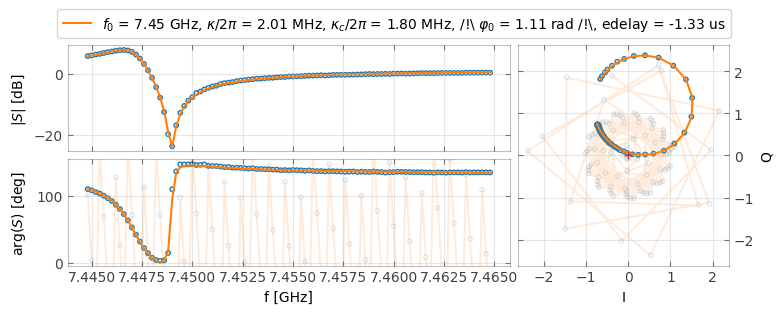

In [ ]:
from single_qubit_pyscrip_v1_3.s002_res_spec_ge import Resonator_onetone

START_FREQ = config['res_freq_ge'][qubit_idx]- 10  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 10   # [MHz]

STEPS = 101


config['res_gain_ge'][qubit_idx] = 0.2
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_freq_ge_mixer', config['res_freq_ge'][qubit_idx]),
                ('relax_delay', 1),
                ('cooling', False)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
fres = await onetone.run(py_avg=1000, liveplot=True, solve_type='hm')

## update value ##
config['res_freq_ge'][qubit_idx] = round(fres[0]/1e6,4)
onetone.saveLabber(qubit_idx, yoko_value=None)


In [23]:
# from single_qubit_pyscrip_v1_3.s002b_res_punchout_ge import SingleToneSpectroscopyPunchout

# run_cfg = select_config_idx(config, qubit_idx)

# START_FREQ = config['res_freq_ge'][qubit_idx]- 4  # [MHz]
# STOP_FREQ = config['res_freq_ge'][qubit_idx] + 4   # [MHz]
# STEPS_freq = 81

# START_gain = 0.01  # [MHz]
# STOP_gain = 0.15  # [MHz]
# STEPS_gain = 51
# run_cfg.update([('f_steps', STEPS_freq), ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
#                ('g_steps', STEPS_gain), ('res_gain_ge', QickSweep1D('gainloop', START_gain, STOP_gain))])
# punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
# punchout.run(py_avg=10, liveplot=True)
# # punchout.saveLabber(qubit_idx)

# Onetone Flux

In [6]:
from single_qubit_pyscrip_v1_3.s002c_res_spec_ge_flux import Resonator_onetone_flux

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 10 # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 10 # [MHz]

STEPS = 200

Start_flux = -12.7
Stop_flux = -12.6
Steps_flux = 2
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)
run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('relax_delay', 1)
                ])

onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
onetone_flux.liveplot_yoko(30, yoko_range, yoko_connect, mode='voltage')
# onetone_flux.saveLabber(qubit_idx, yoko_range, mode='voltage')

FigureWidget({
    'data': [{'showscale': True,
              'type': 'heatmap',
              'uid': 'e101951e-e789-4720-995d-c1d2d283a821',
              'x': {'bdata': 'ZmZmZmZmKcAzMzMzMzMpwA==', 'dtype': 'f8'},
              'y': {'bdata': ('AABwHyINvUAzMxPZOw29QGZmtpJVDb' ... 'rtIL1AmpmpswchvUDNzExtISG9QA=='),
                    'dtype': 'f8'},
              'z': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8',
                    'shape': '200, 2'},
              'zmax': 1.0,
              'zmin': 0.0}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 30},
               'template': '...',
               'title': {'text': 'average: 0 / 30'},
               'xaxis': {'constrain': 'domain', 'title': {'text': 'Voltage (V)'}},
               'yaxis': {'constrain': 'domain', 'title': {'text': 'Frequency (MHz)'}}}
})

yoko sweep:   0%|          | 0/2 [00:00<?, ?it/s]

## Hardware loop

In [115]:
# from single_qubit_pyscrip_v1_1.s002c_res_spec_ge_flux import Resonator_onetone_flux

# run_cfg = select_config_idx(config, qubit_idx)

# START_FREQ = 5000
# STOP_FREQ = 6000
# STEPS = 101
# yoko_range = np.linspace(0, 1, 21)*1e-3
# run_cfg.update([('steps', STEPS),
#                 ('steps_flux', 21),
#                 ('flux_ch', 2),
#                 ('flux_length', 10),
#                 ('saturate_times', 0.5),
#                 ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
#                 ('flux_gain', QickSweep1D('fluxloop', -0.01, 0.01)),
#                 ('relax_delay', 1)
#                 ])

# onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
# onetone_flux.liveplot_hardwre(50)

# Cooling sweep

In [11]:
# from single_qubit_pyscrip_v1_3.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

# run_cfg = select_config_idx(config, qubit_idx)
# SPAN1 = 20
# cooling_freq['f12'] =6.303
# cooling_freq['f0g1'] = 1.290
# START_FREQ_1 =  round(cooling_freq['f12']*1e3,3) - SPAN1 # [MHz]
# STOP_FREQ_1 =   round(cooling_freq['f12']*1e3,3) + SPAN1 # [MHz]
# STEPS_freq_1 = 31

# SPAN2 = 20
# START_FREQ_2 =  round(cooling_freq['f0g1']*1e3,3) - SPAN2 # [MHz]
# STOP_FREQ_2 =   round(cooling_freq['f0g1']*1e3,3) + SPAN2 # [MHz]
# STEPS_freq_2 = 31

# config.update([
#     ('cool_ch1', 5), ('cool_gain_1', 0.5), ('nqz_cool_ch1', 2), ('cool_mixer1', round(cooling_freq['f12']*1e3,3)),
#     ('cool_ch2', 7), ('cool_gain_2', 0.5), ('nqz_cool_ch2', 2), ('cool_mixer2', round(cooling_freq['f0g1']*1e3,3)),
#     ('cool_length', 2)])

# run_cfg.update([('f_steps1', STEPS_freq_1), ('cool_freq_1', QickSweep1D('freqloop1', START_FREQ_1, STOP_FREQ_1)),
#                ('f_steps2', STEPS_freq_2), ('cool_freq_2', QickSweep1D('freqloop2', START_FREQ_2, STOP_FREQ_2))])
# cooling = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
# cooling.run(py_avg=30, liveplot=True)
# cooling.saveLabber(qubit_idx)

In [12]:
# config.update([
#     ('cool_ch1', 5), ('cool_freq_1', 6309), ('cool_gain_1', 0.5), ('nqz_cool_ch1', 2), ('cool_mixer1', 6309),
#     ('cool_ch2', 7), ('cool_freq_2', 1278), ('cool_gain_2', 0.5), ('nqz_cool_ch2', 2), ('cool_mixer2', 1278),
#     ('cool_length', 3)])


# Qubit Spectrum ge

In [24]:
from single_qubit_pyscrip_v1_3.s003_qubit_spec_ge import Qubit_Twotone

center = 5960
# center = round(cooling_freq['f12']*1e3,3)
SPAN = 100
START_FREQ = center - SPAN # [MHz]
STOP_FREQ = center + SPAN  # [MHz]

STEPS = 201

config['nqz_qubit'] = 2

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',center),
                ('qubit_gain_ge', 0.2),
                ('res_gain_ge', 0.3),
                ('qubit_length_ge', 5),
                ('relax_delay',1),
                ('cooling', False),  # Set to False for qubit spectroscopy
                ('qubit_ch',2)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(30, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
# spectrum_ge.saveLabber(qubit_idx, yoko_value=yoko_value)

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': 'Amplitude',
              'type': 'scatter',
              'uid': '08f019b5-3b17-4fcb-93a6-a4b3aa204390',
              'x': {'bdata': ('KVz////jtkDsUfD//+S2QK5H4f//5b' ... 'Bd9P+pt0BmZk70/6q3QClcP/T/q7dA'),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'),
                    'dtype': 'f8'}}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 30},
               'template': '...',
               'title': {'text': 'average: 0 / 30'},
               'xaxis': {'constrain': 'domain', 'title': {'text': 'Frequency (MHz)'}},
               'yaxis': {'constrain': 'domain', 'title': {'text': 'ADC units'}}}
})

average count:   0%|          | 0/30 [00:00<?, ?it/s]

# Qubit Spectrum ge Flux

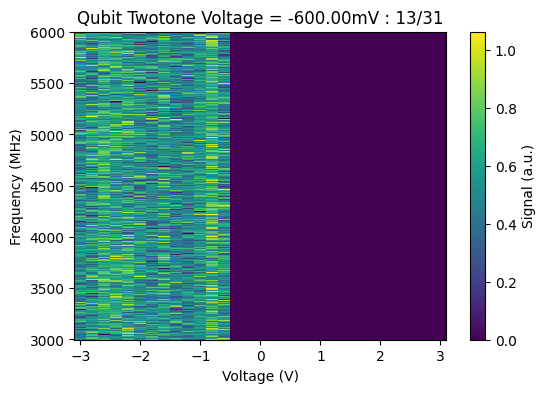

KeyboardInterrupt: 

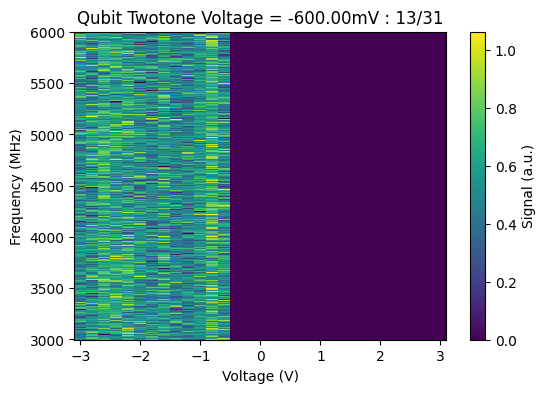

In [ ]:
from single_qubit_pyscrip_v1_3.s003a_qubit_flux_spec_ge import Qubit_Twotone_Flux

run_cfg = select_config_idx(config, qubit_idx)

cemter = 7320
SPAN = 400
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
# 87 = =, by super junior
START_FREQ = 3000 # [MHz]
STOP_FREQ = 6000 # [MHz]
STEPS = 501

Start_flux = -3
Stop_flux = 3
Steps_flux = 31
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)

config['nqz_qubit'] = 2
run_cfg.update([('steps', STEPS),
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixe_freq',cemter),
                ('qubit_gain_ge', 0.8),
                ('res_gain_ge', 0.5),
                ('qubit_length_ge', 2.0),
                ('relax_delay',1),
                ('cooling', False),
                ('qubit_ch', 2)
                ])

spectrum_ge_flux = Qubit_Twotone_Flux(soc, soccfg, run_cfg)
spectrum_ge_flux.liveplot_yoko(50, yoko_range, yoko_connect, mode='voltage')
spectrum_ge_flux.saveLabber(qubit_idx, yoko_range, mode='voltage')

# Power Rabi ge

In [28]:
from single_qubit_pyscrip_v1_3.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config["sigma"][qubit_idx] = 0.15
config['relax_delay'] = 50  # [us]
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ge',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', False),
    ('qubit_ch', 2),
    ('res_gain_ge', 0.3)
    ])

prabi = Amp_Rabi(soc, soccfg, run_cfg)
config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.run(30, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx, yoko_value=yoko_value)

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'name': 'Amplitude',
              'showlegend': False,
              'type': 'scatter',
              'uid': '72d93f6e-410f-4163-a42d-e7eab8626d6a',
              'x': {'bdata': ('AAAAAAAAAAAoBUqBUqCEPygFSoFSoJ' ... 'QL/ULvP+VX+VV+le8/+n/+n//n7z8='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8'}}],
    'layout': {'autosize': True,
               'margin': {'b': 30, 'l': 10, 'pad': 0, 'r': 10, 't': 50},
               'showlegend': False,
               'template': '...',
               'title': {'text': 'average: 0 / 30', 'x': 0.5, 'xanchor': 'center', 'y': 0.95, 'yanchor': 'top'},
               'xaxis': {'constrain': 'domain', 'title': {'text': 'DAC Gain (a.u.)'}},
               'yaxis': {'constrain': 'domain', 'title': {'text': 'ADC units'}}}
})

average count:   0%|          | 0/30 [00:00<?, ?it/s]

Attempted to init fitparam 0 to 0.0, which is out of bounds 0.0 to 0.0. Instead init to 0.0
Attempted to init fitparam 4 to 0.0, which is out of bounds 0.0 to 0.0. Instead init to 0.0


Traceback (most recent call last):
  File "c:\Users\QEL\Anaconda3\envs\qick\lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\QEL\AppData\Local\Temp\ipykernel_48828\738396535.py", line 21, in <module>
    config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.run(30, liveplot=True)
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_3\s005_power_rabi_ge.py", line 174, in run
    return self.liveplot(py_avg)
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_3\s005_power_rabi_ge.py", line 256, in liveplot
    fit_params, error, fig = plot_final2_plotly(
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_3\plot_utils.py", line 1031, in plot_final2_plotly
    popt, pcov, _ = fitfunc(data_dict["xpts"], data_dict[measure])
  File "c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v

# Ramsey

Data save to C:\Users\QEL\Desktop\2D3QFF1\2025\08\Data_0827\s006_Ramsey_ge_Q1_-8.0V


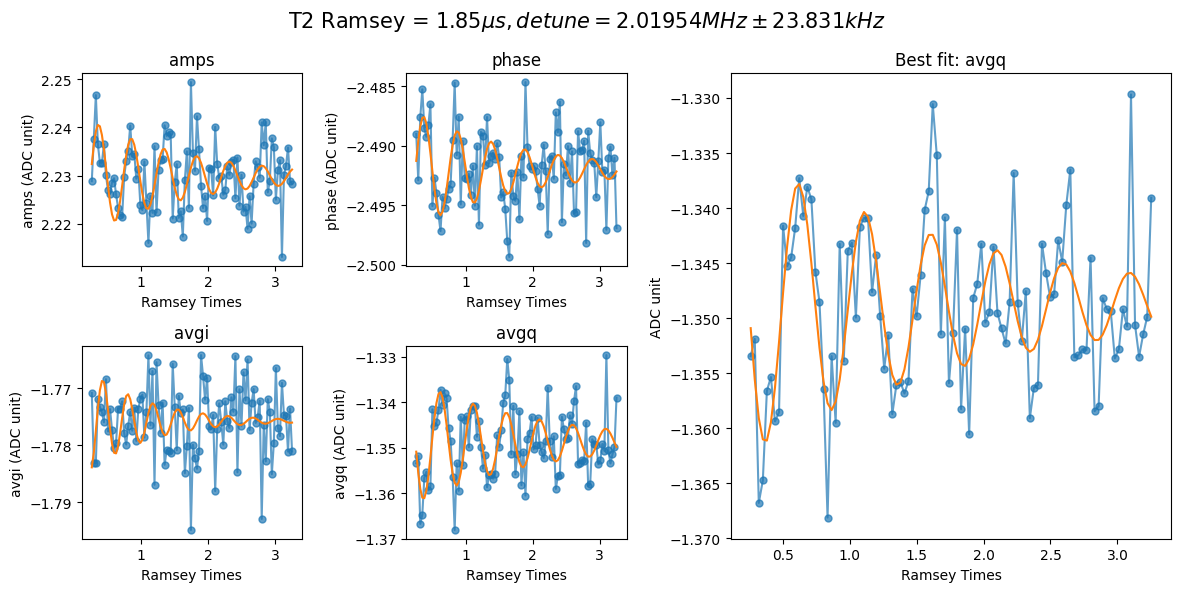

In [ ]:
from single_qubit_pyscrip_v1_3.s006_Ramsey_ge import Ramsey

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 3 # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 1),
    ('cooling', False),
    ('qubit_ch', 2)
    ])

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(100, liveplot=True)
# t2r.plot()
# config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()
t2r.saveLabber(qubit_idx, yoko_value=yoko_value)


In [134]:
config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()

over detune -0.11241MHz


# Echo

Data save to C:\Users\QEL\Desktop\2D3QFF1\2025\08\Data_0822\s007_SpinEcho_ge_Q2_-12.9V


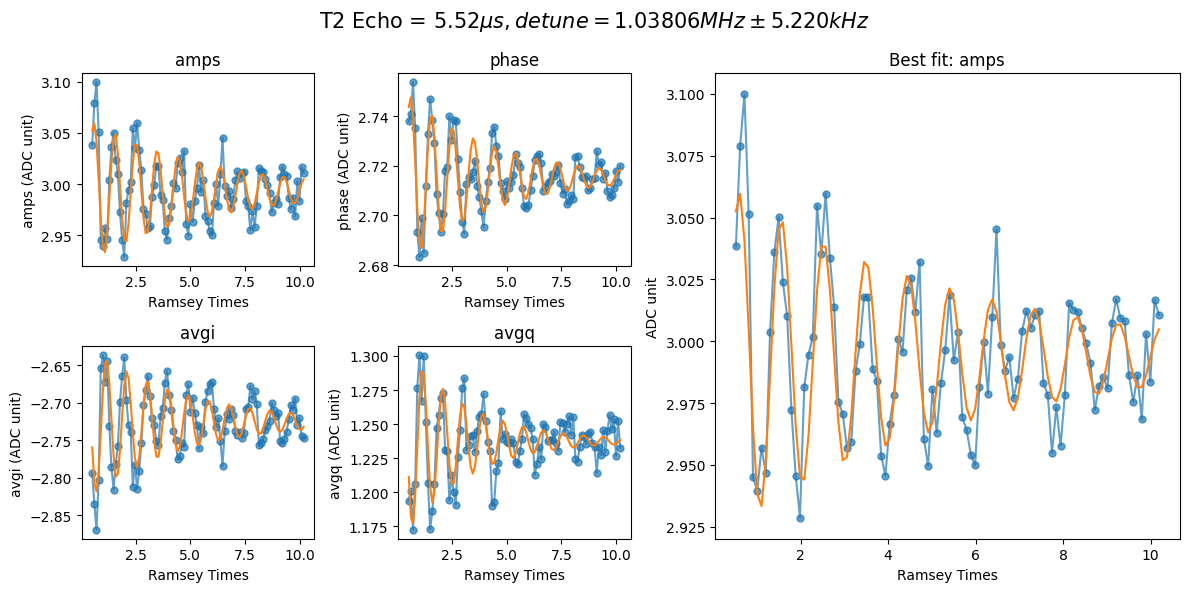

In [ ]:
from single_qubit_pyscrip_v1_3.s007_SpinEcho_ge import SpinEcho

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 1),
    ('cooling', False),
    ('qubit_ch', 7)
    ])

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(20, liveplot=True)
# t2e.plot()
t2e.saveLabber(qubit_idx, yoko_value=yoko_value)

# T1

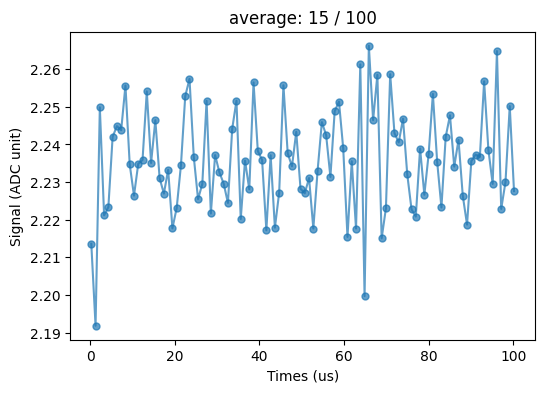

KeyboardInterrupt: 

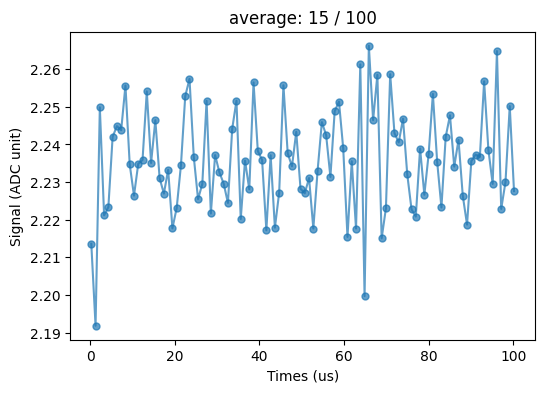

In [ ]:
from single_qubit_pyscrip_v1_3.s008_T1_ge import T1

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 50),
    ('cooling', False),
    ('qubit_ch', 2)
    ])

t1 = T1(soc, soccfg, run_cfg)
t1.run(100, liveplot=True)


t1.saveLabber(qubit_idx, yoko_value=yoko_value)

# Single shot

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

g unrotated averages:
I -2.9246735677083335 +/- 0.5016647245207038 	 Q 1.1244091145833333 +/- 0.4961780943610035 	 Amp 3.1737177010753403 +/- 0.4933431722878828
Rotated (theta=-1.0649852925983965):
I -0.4334416580978772 +/- 0.5028441604295284 	 Q 3.1032466327437187 +/- 0.4949827749266364 	 Amp 3.13337060281893 +/- 0.4933431722878828
e unrotated averages:
I -2.9145977864583332 +/- 0.5062662288067277 	 Q 1.1426006510416669 +/- 0.5012793613808703 	 Amp 3.1713268232707517 +/- 0.5006887028570747
Rotated (theta=-1.0649852925983965):
I -0.4126461449637243 +/- 0.501297788846582 	 Q 3.1032466327437196 +/- 0.5062479821926471 	 Amp 3.130561691548125 +/- 0.5006887028570747


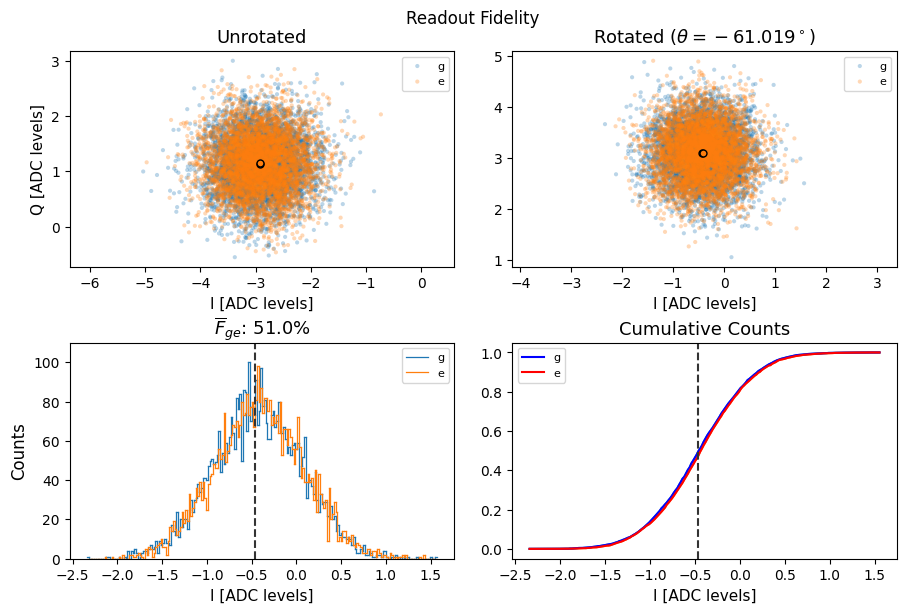

fidelity:[0.5101] 
thressholds:[-0.46178574114009807] 
theta:-61.01916250939318

        Fidelity Matrix:
        -----------------
        | 47.900% | 52.100% |
        ----------------
        | 45.880% | 54.120% |
        -----------------
        IQ plane rotated by: -61.0°
        Threshold: -4.618e-01
        Fidelity: 51.010%
        


In [ ]:
from single_qubit_pyscrip_v1_3.s000_SingleShot_prog import SingleShot_gef
run_cfg = select_config_idx(config, qubit_idx)

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT)
ssh.plot(fid_avg=True)

# Cooling to e

In [4]:
from single_qubit_pyscrip_v1_1.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ_1 =  3150 # [MHz]
STOP_FREQ_1 =   3300 # [MHz]
STEPS_freq_1 = 51

START_FREQ_2 =  1900 # [MHz]
STOP_FREQ_2 =   2050 # [MHz]
STEPS_freq_2 = 51

config.update([
    ('cool_ch1', 5), ('cool_gain_1',0.8), ('nqz_cool_ch1', 2), ('cool_mixer1', 3000),
    ('cool_ch2', 2), ('cool_gain_2',0.4), ('nqz_cool_ch2', 2), ('cool_mixer2', 2000),
    ('cool_length', 1)])

run_cfg.update([('f_steps1', STEPS_freq_1), ('cool_freq_1', QickSweep1D('freqloop1', START_FREQ_1, STOP_FREQ_1)),
               ('f_steps2', STEPS_freq_2), ('cool_freq_2', QickSweep1D('freqloop2', START_FREQ_2, STOP_FREQ_2))
               ])
cooling = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
cooling.run(py_avg=20, liveplot=True)
# cooling.saveLabber(qubit_idx)

KeyboardInterrupt: 

# Onetone EF

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_1\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 7.5215, 'Qi': 27, 'Ql': 1956, 'absQc': -28, 'κ(MHz)': 3.85}


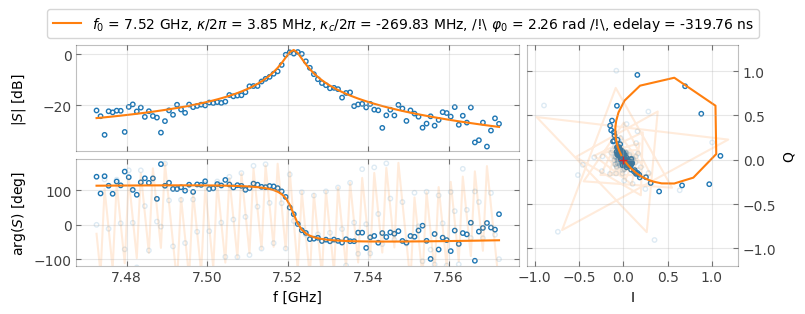

In [ ]:
from single_qubit_pyscrip_v1_1.s009_res_spec_ef import Resonator_onetone_ef


run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 50  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 50   # [MHz]
STEPS = 101
run_cfg.update([('steps', STEPS), 
                ('res_freq_ef', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_gain_ef',0.2),
                ('cooling', False)
                ])

onetone_ef = Resonator_onetone_ef(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = onetone_ef.run(py_avg=10, liveplot=True)
# result = onetone.plot_circle()
## update value ##
config['res_freq_ef'][qubit_idx] = round(fres[0]/1e6,4)
# config['res_freq_ef'][qubit_idx] = config['res_freq_ge'][qubit_idx]
# onetone_ef.saveLabber(qubit_idx, save_sim=True)|

# Qubit Spectrum ef

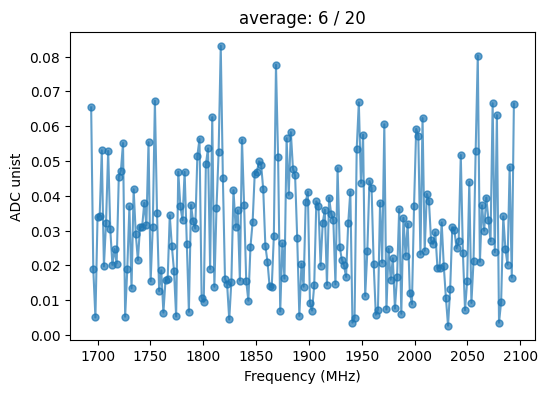

KeyboardInterrupt: 

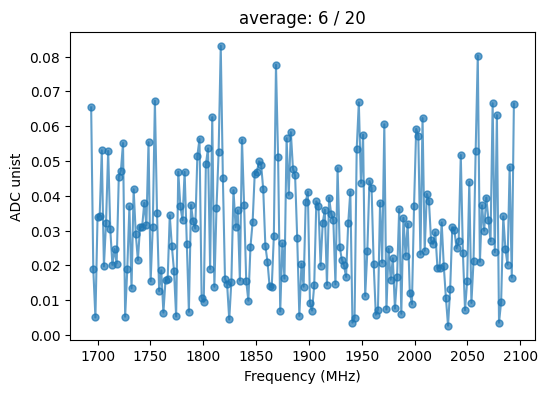

In [142]:
from single_qubit_pyscrip_v1_1.s010_qubit_spec_ef import Qubit_Twotone_ef

run_cfg = select_config_idx(config, qubit_idx)

cemter = 1894
SPAN = 200
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 200

config['qubit_ch_ef'][qubit_idx] = 2


config.update([
    ('nqz_qubit_ef', 2),
])
run_cfg.update([('steps', STEPS),
                ('qubit_freq_ef', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq_ef', 2200),
                ('qubit_gain_ef', 0.2),
                ('nqz_qubit_ef', 2),
                ('relax_delay', 50),
                ('cooling', False),
                ('ge_ref', True),
                ])

spectrum_ge = Qubit_Twotone_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ge.run(20, liveplot=True)
config['qubit_freq_ef'][qubit_idx] = f_ef
config['qmixer_freq_ef'][qubit_idx] = f_ef
spectrum_ge.saveLabber(qubit_idx, save_sim=True)

# Rabi EF

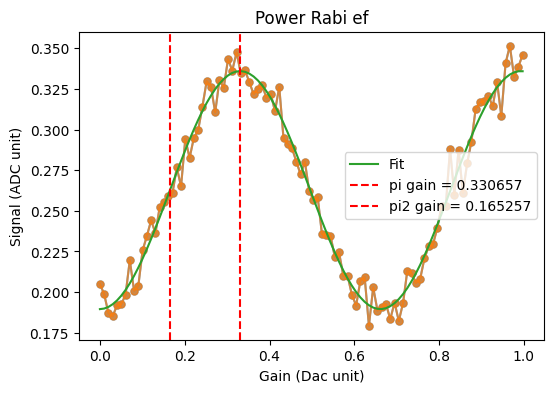

In [349]:
from single_qubit_pyscrip_v1_1.s011_power_rabi_ef import Amp_Rabi_ef


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100


config["sigma_ef"][qubit_idx] = 0.02
config['relax_delay'] = 50
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ef',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', False),
    ('ge_ref', True),
    ])

prabi = Amp_Rabi_ef(soc, soccfg, run_cfg)
config['qubit_pi_gain_ef'][qubit_idx], config['qubit_pi2_gain_ef'][qubit_idx] = prabi.run(50, liveplot=True)
# a, b = prabi.run(50, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx)

# Ramsey ef

over detune 0.02285MHz


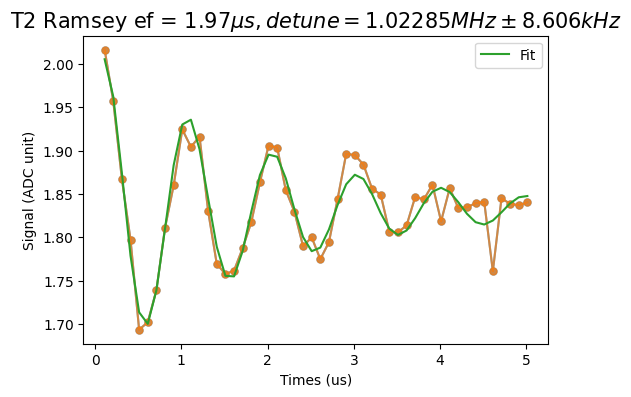

In [351]:
from single_qubit_pyscrip_v1_1.s012_Ramsey_ef import Ramsey_ef

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 50
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 1),
    ('cooling', False),
    ('ge_ref',True),
    ])

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(20, liveplot=True)
# tt2r_ef2r.plot()
config['qubit_freq_ef'][qubit_idx] = t2r_ef.correct_detune()
# t2r_ef.saveLabber(qubit_idx, 0, save_sim=True)


# T1 ef

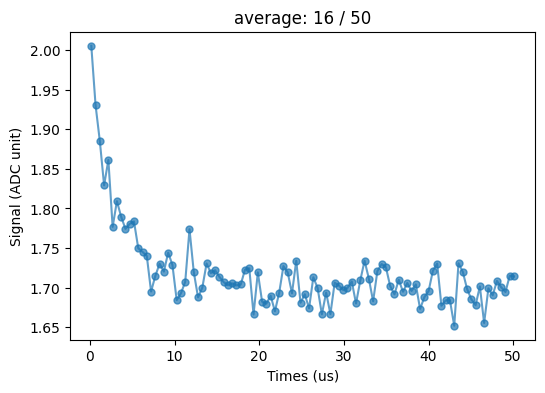

KeyboardInterrupt: 

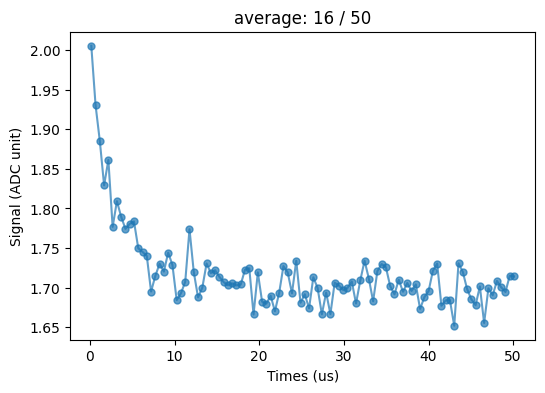

In [352]:
from single_qubit_pyscrip_v1_1.s013_T1_ef import T1_ef

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 100),
    ('cooling', False),
    ('ge_ref', True),

    ])

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50, liveplot=True)


# t1.saveLabber(qubit_idx, 0, save_sim=True)

# Qubit Temperature

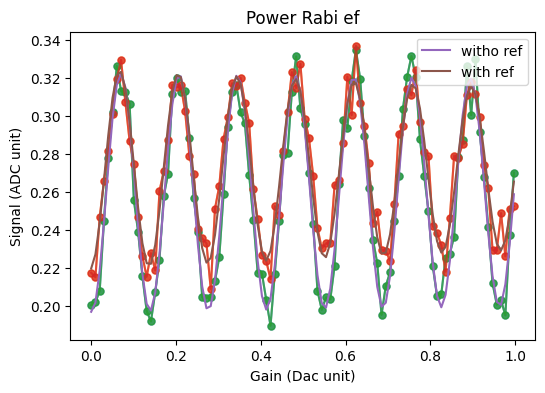

In [353]:
from single_qubit_pyscrip_v1_1.s013_qubit_temp import Qubit_temperature


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100


config["sigma_ef"][qubit_idx] = 0.1
config['relax_delay'] = 100
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ef',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', False),
    ('ge_ref', True),

    ])

prabi = Qubit_temperature(soc, soccfg, run_cfg)
# config['qubit_pi_gain_ef'][qubit_idx], config['qubit_pi2_gain_ef'][qubit_idx] = prabi.run(50, liveplot=True)
x, y =prabi.run(50, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx)

# ALLXY

  0%|          | 0/21 [00:00<?, ?it/s]

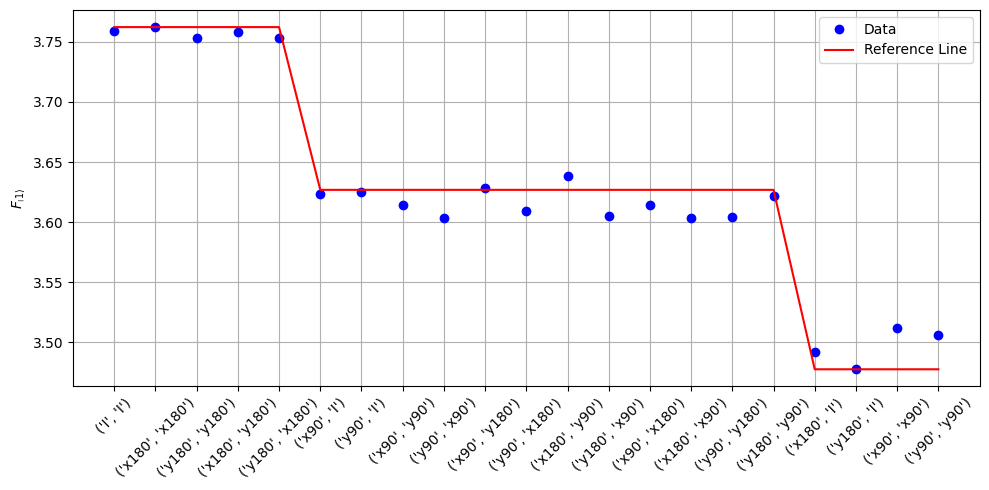

In [ ]:
from single_qubit_pyscrip_v1_3.s014_AllXY import AllXY
run_cfg.update([
    ('cooling', False)
    ])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(50)
allxy.plot()